# What Does It Take to Be a Strong Powerlifter?
### An analysis of 386,000 real competition results from OpenPowerlifting

**Author:** *Your Name* · **Data:** [OpenPowerlifting](https://www.openpowerlifting.org/) public dataset (386,414 competition entries, 8,482 meets, 45 countries, 1974–2018)

---

## Questions this analysis answers

1. **How has the sport of powerlifting evolved?** — participation growth, the rise of women's powerlifting, and the "raw renaissance"
2. **At what age do lifters peak?** — relative strength (Wilks) across the lifespan, by sex
3. **How does strength scale with bodyweight?** — and why per-kg comparisons are misleading
4. **What total should *you* aim for?** — a percentile benchmark calculator by sex and weight class
5. **Can we predict a lifter's total?** — a machine learning model from just 4 features, and what it tells us about what drives strength

## 1 · Setup and data loading

The dataset comes in two tables: one row per **lifter-entry** (lifts, bodyweight, placing) and one row per **meet** (date, federation, country). They join on `MeetID`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

lifts = pd.read_csv("data/openpowerlifting.csv", low_memory=False)
meets = pd.read_csv("data/meets.csv", parse_dates=["Date"])

df = lifts.merge(meets, on="MeetID", how="left")
print(f"Lifter entries: {lifts.shape[0]:,}  |  Meets: {meets.shape[0]:,}  |  Merged: {df.shape}")
df.head(3)

Lifter entries: 386,414  |  Meets: 8,482  |  Merged: (386414, 24)


,MeetID,Name,Sex,Equipment,Age,Division,BodyweightKg,WeightClassKg,Squat4Kg,BestSquatKg,...,TotalKg,Place,Wilks,MeetPath,Federation,Date,MeetCountry,MeetState,MeetTown,MeetName
0,0,Angie Belk Terry,F,Wraps,47.0,Mst 45-49,59.60,60,NaN,47.63,...,138.35,1,155.05,365strong/1601,365Strong,2016-10-29,USA,NC,Charlotte,2016 Junior & Senior National Powerlifting Cha...
1,0,Dawn Bogart,F,Single-ply,42.0,Mst 40-44,58.51,60,NaN,142.88,...,401.42,1,456.38,365strong/1601,365Strong,2016-10-29,USA,NC,Charlotte,2016 Junior & Senior National Powerlifting Cha...
2,0,Dawn Bogart,F,Single-ply,42.0,Open Senior,58.51,60,NaN,142.88,...,401.42,1,456.38,365strong/1601,365Strong,2016-10-29,USA,NC,Charlotte,2016 Junior & Senior National Powerlifting Cha...


## 2 · Data cleaning

Real competition data is messy. Issues found and how they were handled:

| Issue | Finding | Decision |
|---|---|---|
| 4th-attempt columns | >99% missing (they're rare record attempts) | dropped |
| Negative lift values | 3,052 entries — failed attempts are recorded as negative numbers | set to `NaN` |
| Missing age | 62% missing (many federations don't report it) | kept, excluded only from age analyses |
| Implausible bodyweights | a handful outside 30–250 kg | removed |
| Incomplete meets | entries missing a lift or total (bench-only meets, bomb-outs, DQs) | excluded from performance analyses only |

In [2]:
# Drop 4th attempt columns (>99% missing - rare record-only attempts)
df = df.drop(columns=["Squat4Kg", "Bench4Kg", "Deadlift4Kg"])

# Failed attempts are stored as negative numbers -> not real lifts
for c in ["BestSquatKg", "BestBenchKg", "BestDeadliftKg"]:
    n_neg = (df[c] <= 0).sum()
    df.loc[df[c] <= 0, c] = np.nan
    print(f"{c}: nulled {n_neg} failed/invalid attempts")

# Sanity filters
df = df[(df["BodyweightKg"].between(30, 250)) | df["BodyweightKg"].isna()]
df.loc[~df["Age"].between(5, 95), "Age"] = np.nan
df["Year"] = df["Date"].dt.year

# Performance subset: full-power entries (squat + bench + deadlift + valid total)
sbd = df.dropna(subset=["TotalKg", "BodyweightKg", "BestSquatKg", "BestBenchKg", "BestDeadliftKg"])
sbd = sbd[sbd["TotalKg"] > 0]
print(f"\nClean full-power entries for performance analysis: {len(sbd):,} ({len(sbd)/len(df):.0%} of merged data)")

BestSquatKg: nulled 985 failed/invalid attempts
BestBenchKg: nulled 1556 failed/invalid attempts
BestDeadliftKg: nulled 511 failed/invalid attempts



Clean full-power entries for performance analysis: 285,546 (74% of merged data)


## 3 · The growth of powerlifting — and the rise of women's lifting

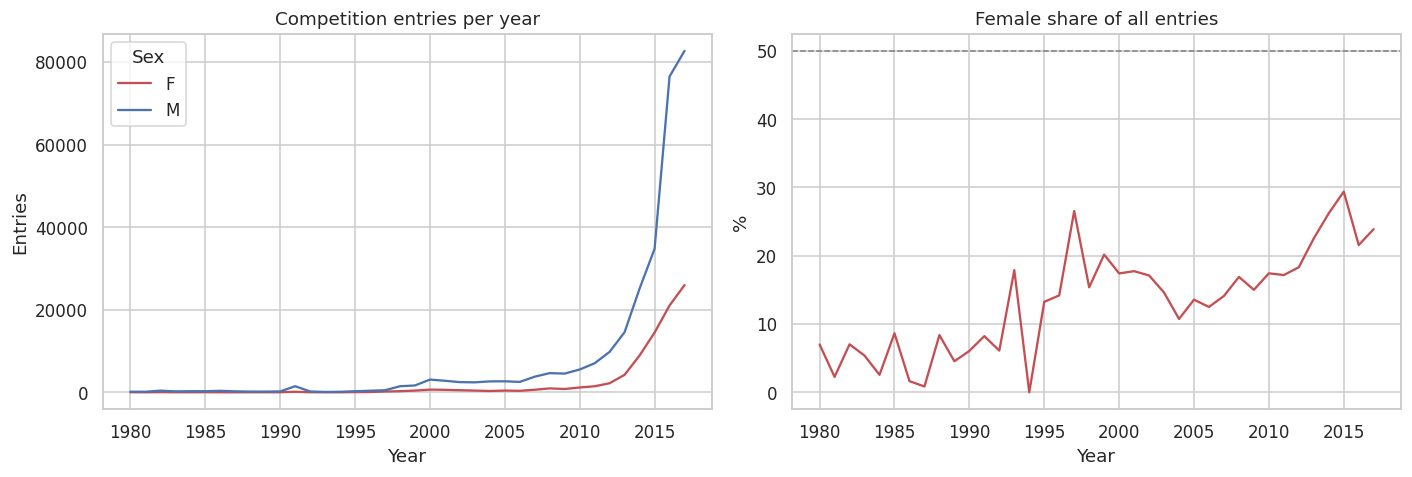

Female share of entries: 6.1% in 1990  ->  23.9% in 2017


In [3]:
per_year = df.groupby(["Year", "Sex"]).size().unstack(fill_value=0)
per_year = per_year.loc[1980:2017]  # 2018 is a partial year in this snapshot

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
per_year.plot(ax=axes[0], color=["#c44e52", "#4c72b0"])
axes[0].set_title("Competition entries per year")
axes[0].set_ylabel("Entries")

female_share = per_year["F"] / per_year.sum(axis=1) * 100
female_share.plot(ax=axes[1], color="#c44e52")
axes[1].set_title("Female share of all entries")
axes[1].set_ylabel("%")
axes[1].axhline(50, ls="--", c="gray", lw=1)

plt.tight_layout()
plt.savefig("figures/01_participation.png", bbox_inches="tight")
plt.show()

print(f"Female share of entries: {female_share.loc[1990]:.1f}% in 1990  ->  {female_share.loc[2017]:.1f}% in 2017")

**Insight:** Powerlifting grew explosively after ~2010, and women drove a disproportionate share of that growth — from **~6% of entries in 1990 to ~24% by 2017**, quadrupling their representation.

## 4 · The "raw renaissance"

Powerlifting equipment matters: supportive squat suits and bench shirts ("Single-ply"/"Multi-ply") add substantial kilos. Around 2010 the sport saw a cultural shift back to **Raw** (belt only) lifting.

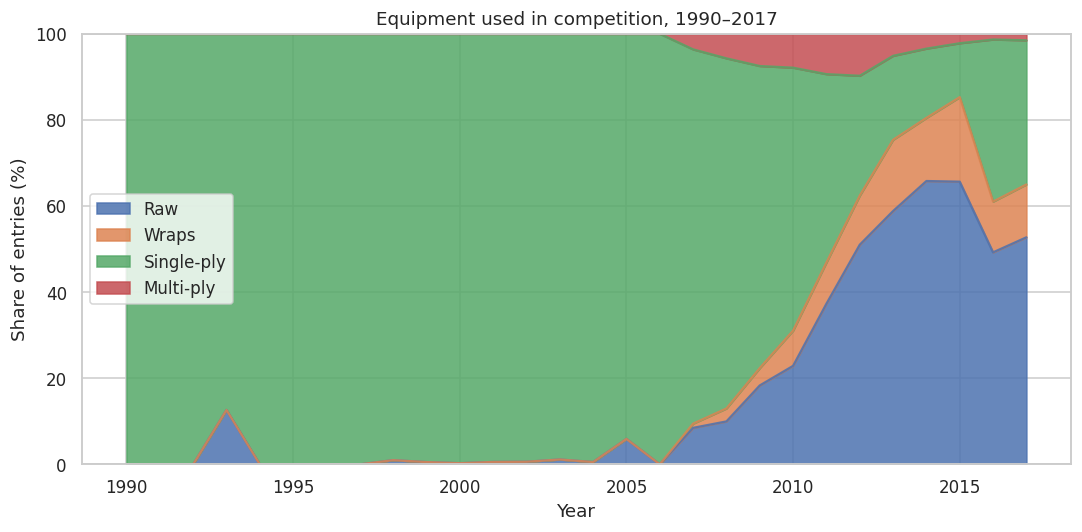

Raw share of entries: 0.3% in 2000  ->  52.7% in 2017


In [4]:
eq = df[df["Year"].between(1990, 2017)]
eq_share = eq.groupby(["Year", "Equipment"]).size().unstack(fill_value=0)
eq_share = eq_share[["Raw", "Wraps", "Single-ply", "Multi-ply"]]
eq_share = eq_share.div(eq_share.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
eq_share.plot.area(ax=ax, alpha=0.85)
ax.set_ylabel("Share of entries (%)")
ax.set_ylim(0, 100)
ax.set_title("Equipment used in competition, 1990–2017")
ax.legend(loc="center left")
plt.tight_layout()
plt.savefig("figures/02_raw_renaissance.png", bbox_inches="tight")
plt.show()

print(f"Raw share of entries: {eq_share.loc[2000,'Raw']:.1f}% in 2000  ->  {eq_share.loc[2017,'Raw']:.1f}% in 2017")

**Insight:** Raw lifting went from a rounding error (**0.3% of entries in 2000**) to the majority of the sport (**53% by 2017**) — one of the fastest equipment-culture shifts in any strength sport. Any historical comparison of totals that ignores equipment is invalid.

## 5 · At what age do lifters peak?

To compare across bodyweights we use the **Wilks score** — a coefficient-adjusted total designed to make lifters of different bodyweights comparable. (Age is missing for 62% of entries; this analysis uses the ~38% of entries where federations reported it.)

Entries with age + Wilks: 105,335


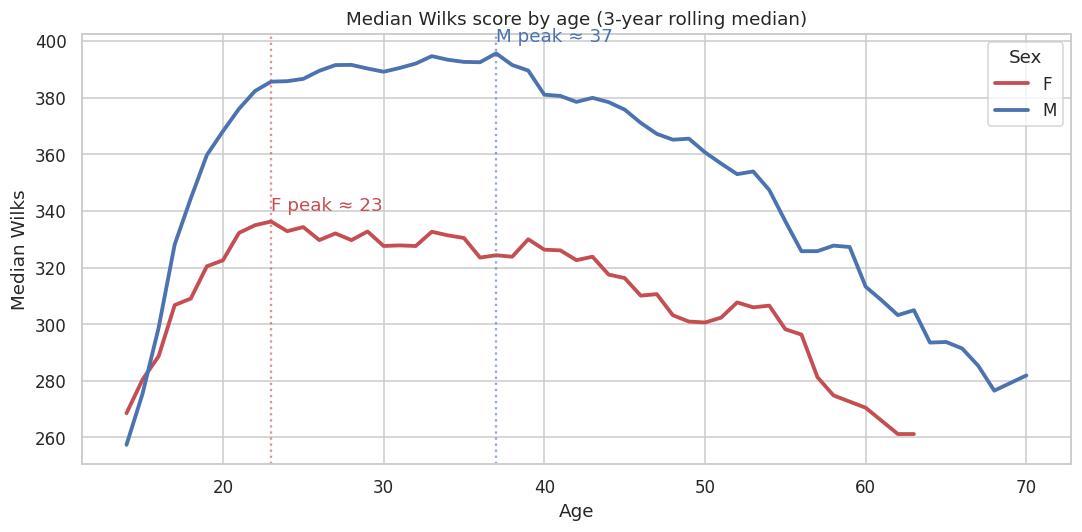

In [5]:
age_df = sbd.dropna(subset=["Age", "Wilks"]).query("14 <= Age <= 70 and Wilks > 0")
print(f"Entries with age + Wilks: {len(age_df):,}")

curve = age_df.groupby([age_df["Age"].round(), "Sex"])["Wilks"].median().unstack()
counts = age_df.groupby([age_df["Age"].round(), "Sex"]).size().unstack()
curve = curve.where(counts >= 100)          # need >=100 lifters per age point
smooth = curve.rolling(3, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(10, 5))
smooth.plot(ax=ax, color=["#c44e52", "#4c72b0"], lw=2.5)
for sex, col in [("M", "#4c72b0"), ("F", "#c44e52")]:
    peak_age = smooth[sex].idxmax()
    ax.axvline(peak_age, color=col, ls=":", alpha=0.6)
    ax.annotate(f"{sex} peak ≈ {peak_age:.0f}", (peak_age, smooth[sex].max()+4), color=col)
ax.set_title("Median Wilks score by age (3-year rolling median)")
ax.set_xlabel("Age"); ax.set_ylabel("Median Wilks")
plt.tight_layout()
plt.savefig("figures/03_age_curve.png", bbox_inches="tight")
plt.show()

**Insight:** Relative strength rises steeply through the teens, then forms a long, surprisingly **flat plateau from the mid-20s through the late 30s** before declining ~1–2 Wilks points per year after 40. Powerlifting rewards training age, not just biological youth — a 38-year-old median competitor is roughly as strong (pound-for-pound) as a 25-year-old one. *Caveat: this is cross-sectional competition data, so selection effects (who keeps competing) partly shape the curve.*

## 6 · Strength vs bodyweight — why absolute totals mislead

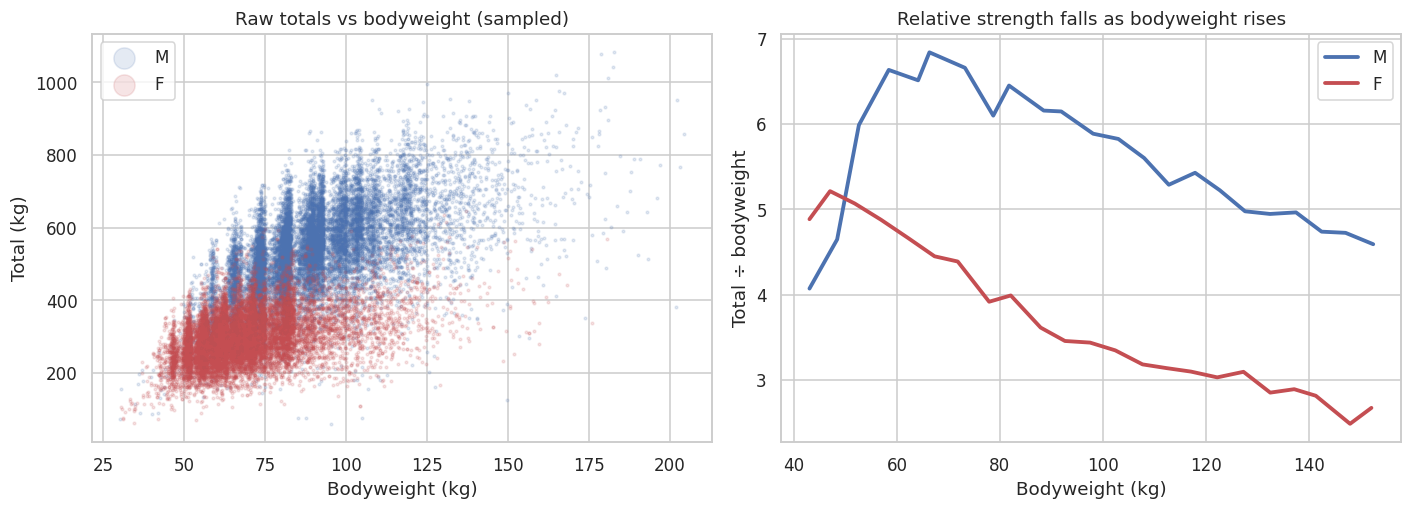

In [6]:
raw = sbd[sbd["Equipment"] == "Raw"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for sex, col in [("M", "#4c72b0"), ("F", "#c44e52")]:
    sub = raw[raw.Sex == sex].sample(min(15000, (raw.Sex == sex).sum()), random_state=0)
    axes[0].scatter(sub.BodyweightKg, sub.TotalKg, s=3, alpha=0.15, color=col, label=sex)
axes[0].set_xlabel("Bodyweight (kg)"); axes[0].set_ylabel("Total (kg)")
axes[0].set_title("Raw totals vs bodyweight (sampled)")
axes[0].legend(markerscale=8)

# Median total and relative strength by bodyweight bin
bins = np.arange(40, 160, 5)
for sex, col in [("M", "#4c72b0"), ("F", "#c44e52")]:
    sub = raw[raw.Sex == sex]
    med = sub.groupby(pd.cut(sub.BodyweightKg, bins), observed=True).agg(
        bw=("BodyweightKg", "median"), total=("TotalKg", "median"))
    axes[1].plot(med.bw, med.total / med.bw, color=col, lw=2.5, label=sex)
axes[1].set_xlabel("Bodyweight (kg)"); axes[1].set_ylabel("Total ÷ bodyweight")
axes[1].set_title("Relative strength falls as bodyweight rises")
axes[1].legend()
plt.tight_layout()
plt.savefig("figures/04_bodyweight_scaling.png", bbox_inches="tight")
plt.show()

**Insight:** Absolute totals rise with bodyweight, but **relative strength (total ÷ bodyweight) steadily falls** — classic allometric scaling (muscle cross-section grows slower than mass). This is exactly why formulas like Wilks/DOTS exist, and why "he lifts 2× bodyweight" means something very different at 60 kg vs 120 kg.

## 7 · Benchmark yourself: what total puts you in the top X%?

Percentile tables of **raw competition totals** (ages 18–45) by sex and IPF-style weight class — plus a lookup function. Remember: this is the distribution of *people who compete*, already a strong, self-selected group.

In [7]:
bench_pool = sbd[(sbd["Equipment"] == "Raw") & sbd["Age"].between(18, 45)]

def percentile_table(sex, bins, labels):
    sub = bench_pool[bench_pool.Sex == sex]
    tbl = sub.groupby(pd.cut(sub.BodyweightKg, bins, labels=labels), observed=True)["TotalKg"] \
             .quantile([0.25, 0.50, 0.75, 0.90, 0.99]).unstack().round(0)
    tbl.columns = ["25th", "50th (median)", "75th", "90th", "99th"]
    tbl.index.name = "Weight class (kg)"
    return tbl

m_bins = [0, 59, 66, 74, 83, 93, 105, 120, 999]
m_lbls = ["-59", "-66", "-74", "-83", "-93", "-105", "-120", "120+"]
f_bins = [0, 47, 52, 57, 63, 69, 76, 84, 999]
f_lbls = ["-47", "-52", "-57", "-63", "-69", "-76", "-84", "84+"]

print("MEN — raw total (kg) percentiles among competitors aged 18–45")
display(percentile_table("M", m_bins, m_lbls))
print("WOMEN — raw total (kg) percentiles among competitors aged 18–45")
display(percentile_table("F", f_bins, f_lbls))

MEN — raw total (kg) percentiles among competitors aged 18–45


,25th,50th (median),75th,90th,99th
Weight class (kg),,,,,
-59,368.0,418.0,468.0,518.0,587.0
-66,410.0,455.0,505.0,558.0,641.0
-74,448.0,500.0,548.0,598.0,680.0
-83,480.0,535.0,592.0,642.0,735.0
-93,515.0,570.0,630.0,682.0,785.0
-105,545.0,605.0,668.0,730.0,822.0
-120,570.0,640.0,710.0,778.0,890.0
120+,610.0,692.0,780.0,850.0,992.0


WOMEN — raw total (kg) percentiles among competitors aged 18–45


,25th,50th (median),75th,90th,99th
Weight class (kg),,,,,
-47,220.0,262.0,298.0,325.0,372.0
-52,245.0,273.0,305.0,340.0,410.0
-57,252.0,285.0,320.0,352.0,420.0
-63,262.0,298.0,335.0,372.0,448.0
-69,270.0,305.0,342.0,380.0,460.0
-76,285.0,325.0,365.0,400.0,480.0
-84,292.0,338.0,383.0,427.0,520.0
84+,302.0,350.0,402.0,452.0,546.0


In [8]:
def where_do_i_rank(sex, bodyweight_kg, total_kg):
    """Percentile of a raw total among competitors (18-45) within ±5 kg bodyweight."""
    pool = bench_pool[(bench_pool.Sex == sex) &
                      (bench_pool.BodyweightKg.between(bodyweight_kg - 5, bodyweight_kg + 5))]
    pct = (pool["TotalKg"] < total_kg).mean() * 100
    print(f"{sex}, {bodyweight_kg} kg, {total_kg} kg total -> "
          f"{pct:.0f}th percentile of {len(pool):,} comparable competitors")

# Examples — plug in your own numbers
where_do_i_rank("M", 83, 500)
where_do_i_rank("M", 83, 600)
where_do_i_rank("F", 63, 300)

M, 83 kg, 500 kg total -> 29th percentile of 8,514 comparable competitors
M, 83 kg, 600 kg total -> 75th percentile of 8,514 comparable competitors
F, 63 kg, 300 kg total -> 48th percentile of 6,535 comparable competitors


## 8 · Predicting a lifter's total with machine learning

Can just **four features** — sex, equipment, age, bodyweight — predict a competition total? A linear baseline vs gradient boosting:

In [9]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

model_df = sbd.dropna(subset=["Age"])
model_df = model_df[model_df["Equipment"].isin(["Raw", "Wraps", "Single-ply", "Multi-ply"])]
X = pd.get_dummies(model_df[["Sex", "Equipment", "Age", "BodyweightKg"]], drop_first=True)
y = model_df["TotalKg"]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training on {len(X_tr):,} entries, testing on {len(X_te):,}")

results = {}
for name, model in [("Linear regression", LinearRegression()),
                    ("Gradient boosting", HistGradientBoostingRegressor(random_state=42))]:
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    results[name] = (model, pred)
    print(f"{name:20s}  R² = {r2_score(y_te, pred):.3f}   MAE = {mean_absolute_error(y_te, pred):.1f} kg")

Training on 85,348 entries, testing on 21,338
Linear regression     R² = 0.686   MAE = 76.0 kg


Gradient boosting     R² = 0.777   MAE = 64.1 kg


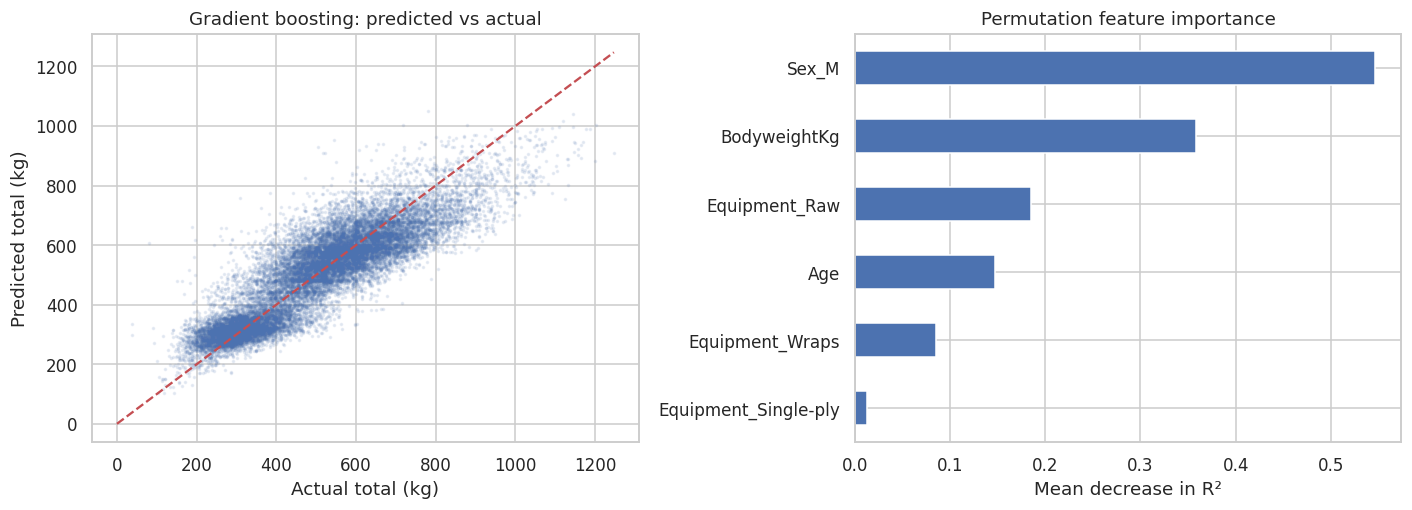

In [10]:
gbm, pred = results["Gradient boosting"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].scatter(y_te, pred, s=2, alpha=0.1, color="#4c72b0")
lims = [0, y_te.max()]
axes[0].plot(lims, lims, "r--", lw=1.5)
axes[0].set_xlabel("Actual total (kg)"); axes[0].set_ylabel("Predicted total (kg)")
axes[0].set_title("Gradient boosting: predicted vs actual")

imp = permutation_importance(gbm, X_te.sample(20000, random_state=0),
                             y_te.sample(20000, random_state=0), n_repeats=5, random_state=0)
imp_s = pd.Series(imp.importances_mean, index=X.columns).sort_values()
imp_s.plot.barh(ax=axes[1], color="#4c72b0")
axes[1].set_title("Permutation feature importance")
axes[1].set_xlabel("Mean decrease in R²")
plt.tight_layout()
plt.savefig("figures/05_model.png", bbox_inches="tight")
plt.show()

## 9 · SQL analysis

The same questions can be answered in SQL. Here the dataset is loaded into a **SQLite** database and queried with multi-table `JOIN`s, `GROUP BY` aggregations, and **window functions** — the same patterns used in production analytics databases.

In [11]:
import sqlite3

conn = sqlite3.connect("powerlifting.db")
lifts.to_sql("lifts", conn, if_exists="replace", index=False)
meets.to_sql("meets", conn, if_exists="replace", index=False)

# helper to run a query and return a DataFrame
q = lambda sql: pd.read_sql_query(sql, conn)

q("SELECT COUNT(*) AS lifter_entries FROM lifts").join(
    q("SELECT COUNT(*) AS meets FROM meets"))

,lifter_entries,meets
0,386414,8482


**Query 1 — JOIN + GROUP BY:** which federations host the most entries, and how strong are their lifters on average?

In [12]:
q("""
SELECT
    m.Federation,
    COUNT(*)                    AS entries,
    COUNT(DISTINCT l.MeetID)    AS meets,
    ROUND(AVG(l.TotalKg), 1)    AS avg_total_kg,
    ROUND(AVG(l.Wilks), 1)      AS avg_wilks
FROM lifts l
JOIN meets m ON m.MeetID = l.MeetID
WHERE l.TotalKg > 0
GROUP BY m.Federation
ORDER BY entries DESC
LIMIT 10
""")

,Federation,entries,meets,avg_total_kg,avg_wilks
0,USAPL,73317,975,416.7,311.1
1,USPA,53741,864,419.3,297.1
2,THSPA,52666,670,449.6,308.6
3,NSF,28965,2517,361.3,247.9
4,CPU,28304,969,420.5,300.8
5,RPS,22663,334,452.4,310.9
6,SPF,17653,480,456.4,305.5
7,PA,12101,493,422.6,307.7
8,NASA,8814,103,352.1,250.1
9,IPF,8682,78,578.2,437.3


**Query 2 — aggregation with conditional logic:** the growth of women's participation by decade (SQL version of Section 3).

In [13]:
q("""
SELECT
    (CAST(strftime('%Y', m.Date) AS INT) / 10) * 10  AS decade,
    COUNT(*)                                          AS entries,
    ROUND(100.0 * SUM(CASE WHEN l.Sex = 'F' THEN 1 ELSE 0 END) / COUNT(*), 1) AS female_pct
FROM lifts l
JOIN meets m ON m.MeetID = l.MeetID
WHERE m.Date >= '1980-01-01'
GROUP BY decade
ORDER BY decade
""")

,decade,entries,female_pct
0,1980,2491,4.9
1,1990,7505,15.2
2,2000,37179,15.2
3,2010,338222,23.8


**Query 3 — window functions:** the top 3 raw lifters by Wilks *within each men's weight class*, using `ROW_NUMBER() OVER (PARTITION BY ...)`.

In [14]:
q("""
WITH best_per_lifter AS (
    SELECT
        Name,
        WeightClassKg,
        MAX(Wilks)   AS best_wilks,
        MAX(TotalKg) AS best_total
    FROM lifts
    WHERE Equipment = 'Raw'
      AND Sex = 'M'
      AND Wilks IS NOT NULL
      AND WeightClassKg IN ('66', '74', '83', '93', '105')
    GROUP BY Name, WeightClassKg
),
ranked AS (
    SELECT *,
        ROW_NUMBER() OVER (
            PARTITION BY WeightClassKg
            ORDER BY best_wilks DESC
        ) AS rank_in_class
    FROM best_per_lifter
)
SELECT WeightClassKg, rank_in_class, Name, best_total, best_wilks
FROM ranked
WHERE rank_in_class <= 3
ORDER BY CAST(WeightClassKg AS REAL), rank_in_class
""")

,WeightClassKg,rank_in_class,Name,best_total,best_wilks
0,66,1,Keith McHoney,692.5,545.11
1,66,2,Sergey Gladkikh,680.0,535.87
2,66,3,Tsung-Ting Hsieh,655.0,528.86
3,74,1,Kjell Egil Bakkelund,757.0,546.47
4,74,2,Taylor Atwood,750.0,542.20
5,74,3,Aliaksandr Hrynkevich-Sudnik,730.0,526.31
6,83,1,Brett Gibbs,814.0,543.93
7,83,2,John Haack,813.0,543.46
8,83,3,Ulan Anuar,795.0,532.96
9,93,1,Brett Gibbs,832.5,541.37


In [15]:
conn.close()

**Insight:** Four demographic features explain **~78% of the variance** in competition totals (MAE ≈ 64 kg), with gradient boosting beating the linear baseline by ~9 points of R² — the age and bodyweight effects are clearly non-linear. **Sex is by far the strongest predictor**, followed by bodyweight. The remaining ~22% is the interesting part: training history, technique, and genetics — none of which are in the data. In other words: demographics set the baseline, training determines where you land around it.

## 10 · Summary of findings

1. **Powerlifting boomed after 2010**, and women quadrupled their share of entries (6% → 24%, 1990–2017).
2. **The raw renaissance is real**: raw lifting went from 0.3% of entries (2000) to 53% (2017), so equipment must be controlled for in any historical comparison.
3. **Peak relative strength is a plateau, not a point** — roughly ages 25–38 — with only gradual decline after 40.
4. **Relative strength falls as bodyweight rises**, which is why coefficient scores (Wilks/DOTS) exist.
5. **A 4-feature model predicts totals with R² ≈ 0.78** — demographics set your baseline; the unexplained 22% is where training matters.

### Limitations & next steps
- Cross-sectional data → age curve confounded by selection (who keeps competing).
- Age missing for 62% of entries (federation reporting differences) → age analyses use a subset.
- Snapshot ends early 2018; the live OpenPowerlifting dataset (3M+ entries) would allow within-lifter longitudinal progression modeling — the natural next step.